In [1]:
import os

import shutil
import warnings

warnings.filterwarnings('ignore')

import os

import numpy as np
import torch

import ViMST as vim 
from pathlib import Path
import scanpy as sc
import pandas as pd
from sklearn import metrics
from sklearn.metrics import adjusted_rand_score as ari_score
import random
from s_dbw import S_Dbw
from scipy.spatial import distance

def train_one(args, adata, tissue_name=' '):
    net = vim.ViMST(adata,
                     tissue_name=tissue_name,
                     num_clusters=args.n_clusters,
                     genes_model='pca',
                     top_genes=args.top_genes,
                     rad_cutoff=args.rad_cutoff,
                     k_cutoff=args.k_cutoff,
                     graph_model='KNN',    #Radius
                     device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
                     learning_rate=args.learning_rate,
                     weight_decay=args.weight_decay,
                     max_epoch=args.max_epoch,
                     gradient_clipping=args.gradient_clipping,
                     feat_mask_rate=args.feat_mask_rate,
                     img_mask_rate=args.img_mask_rate,
                     edge_drop_rate=args.edge_drop_rate,
                     hidden_dim=args.hidden_dim,
                     latent_dim=args.latent_dim,
                     bn=args.bn,\
                     
                     
                     att_dropout_rate=args.att_dropout_rate,
                     fc_dropout_rate=args.fc_dropout_rate,
                     use_token=args.use_token,
                     rep_loss=args.rep_loss,
                     rel_loss=args.rel_loss,
                     alpha=args.alpha,
                     lam=args.lam,
                     random_seed=args.seed,
                     nps=args.nps)

    net.train()
    method = "kmeans"
    net.process(method=method)
    # net.clustering(method=method)
    adata = net.get_adata()
    adata.obs["refined_pred"] = vim.utils.spatial_domains_refinement_ez_mode(sample_id=adata.obs.index.tolist(),
                                                                       pred=adata.obs["kmeans"].tolist(), x_array=adata.obs['array_row'],
                                                                       y_array=adata.obs['array_col'], shape="hexagon")
    adata.obs["refined_pred"] = adata.obs["kmeans"].astype('category') 
    #sub_adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
    #print(f"adata.obsm['eval_pred'].shape: {adata.obsm['eval_pred'].shape}")
    #ARI = ari_score(sub_adata.obs['Ground Truth'], sub_adata.obs['mclust'])
    #NMI = metrics.normalized_mutual_info_score(sub_adata.obs['Ground Truth'], sub_adata.obs[method])
    #print(f"ARI:{ARI}\tNMI:{NMI}")
    return adata

In [2]:
adata = sc.read("/home/dingcheng/data/pacer1/filtered_feature_bc_matrix.h5ad")
from ViMST.utils import build_args

# 初始化其他参数
args = build_args()
args.hidden_dim, args.latent_dim = 256, 128  
args.max_epoch = 500
args.top_genes = 3000
args.n_clusters = 3 
args.lam = 1.3
args.feat_mask_rate = 0.5
args.img_mask_rate = 0.2
#最佳
args.k_cutoff = 6 #定了
args.nps = 4 #定了40
args.edge_drop_rate = 0.6 #定了

adata = train_one(args, adata, "pacer")


adata.obsm['feat'].shape:(4045, 200)
gene_recon 维度: torch.Size([4045, 3000])
adata.obsm['fea1'].shape:(4045, 200)
------Calculating spatial graph...
The graph contains 24270 edges, 4045 cells.
6.0000 neighbors per cell on average.
(4045, 200)


Dataset_Name:pacer, Ep 499: train loss:0.2312: 100%|██████████| 500/500 [01:42<00:00,  4.89it/s]


Calculateing adj matrix using xy only...


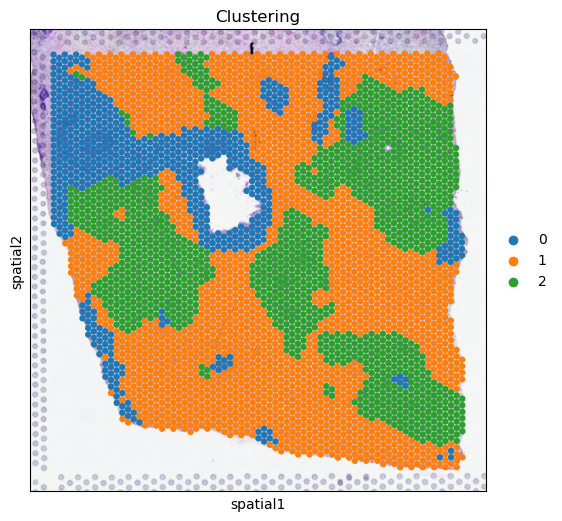

In [3]:
import json
import numpy as np
from skimage import io
import scanpy as sc
import matplotlib.pyplot as plt

# 假设图像和缩放因子文件路径
img_file = "/home/dingcheng/data/pacer1/spatial/tissue_lowres_image.png"
scalefactors_file = "/home/dingcheng/data/pacer1/spatial/scalefactors_json.json"

# 读取空间图像文件
lowres_img = io.imread(img_file)
lowres_img = lowres_img.astype(np.float32) / 255.0

# 读取缩放因子
with open(scalefactors_file, 'r') as f:
    scalefactors = json.load(f)

# 确保 adata 是一个已经存在的 AnnData 对象
# adata = ...  # 这里应该有一个 AnnData 对象的实例化或赋值

# 设置 adata.uns['spatial']，这里我们假设只有一个库，名为 'library1'
adata.uns['spatial'] = {
    'library1': {
        'images': {
            'lowres': lowres_img
        },
        'scalefactors': scalefactors
    }
}

plt.rcParams["figure.figsize"] = (6, 6)
# 使用 sc.pl.spatial 绘制空间图，指定 library_id

sc.pl.spatial(adata, color='refined_pred', title='Clustering', size=1.5, img_key='lowres', library_id='library1')



In [4]:

# 然后将其转换为有序类别
adata.obs["refined_pred"] = adata.obs["refined_pred"].cat.as_ordered()


dav = metrics.davies_bouldin_score(adata.obsm['eval_pred'], adata.obs["refined_pred"])
cal = metrics.calinski_harabasz_score(adata.obsm['eval_pred'], adata.obs["refined_pred"])
sil = metrics.silhouette_score(adata.obsm['eval_pred'], adata.obs["refined_pred"])



sdbw = np.round(S_Dbw(adata.obsm['eval_pred'], adata.obs["refined_pred"]), 5)
# Ann_df = pd.read_csv('./metadata.tsv', sep='\t')
# ARI = np.round(metrics.adjusted_rand_score(y_pred, Ann_df['fine_annot_type']), 3)
# NMI = np.round(metrics.normalized_mutual_info_score(y_pred, Ann_df['fine_annot_type']), 3)
print("dav:", dav)
print("cal:", cal)
print("sil:", sil)
print("sdbw:", sdbw)


dav: 1.7179431581468654
cal: 885.9116784716903
sil: 0.19305772
sdbw: 0.87034


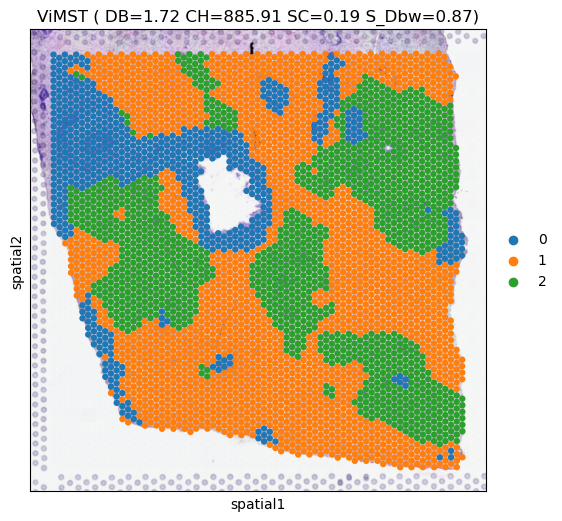

<Figure size 600x600 with 0 Axes>

In [5]:
# 绘制聚类图并保存为 PDF 文件
sc.pl.spatial(adata, color=["refined_pred"], title='ViMST ( DB=%.2f CH=%.2f SC=%.2f S_Dbw=%.2f)' % (dav, cal, sil, sdbw),size=1.5, img_key='lowres', library_id='library1')
save_path = f'/home/Data/Results_pacer/ViMST_Results/pacer_cluster.pdf'
plt.savefig(save_path, dpi=600)


# 保存 .h5ad 文件
adata.write(f'/home/Data/Results_pacer/ViMST_Results/pacer_results.h5ad')